In [1]:
import sys
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

## Reduce Data to 4M "without affecting rare attacks"

In [2]:
file_path = "cic.csv"
output_file = "reduced_4m.csv"

if os.path.exists(output_file):
    os.remove(output_file)

target_total = 4_000_000
target_normal = int(target_total * 0.55)   # 2,200,000
target_attack = int(target_total * 0.45)   # 1,800,000

max_per_attack = 300_000
chunksize = 1_000_000

In [ ]:
from collections import Counter

attack_counts = Counter()

for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk["Label"] = chunk["Label"].astype(str).str.strip()
    chunk["binary_label"] = np.where(
        chunk["Label"].str.contains("BENIGN", case=False),
        0, 1
    )
    
    attack_only = chunk[chunk["binary_label"] == 1]
    attack_counts.update(attack_only["Label"].value_counts().to_dict())

print(dict(attack_counts))

In [5]:
attack_cap_counts = {
    label: min(count, max_per_attack)
    for label, count in attack_counts.items()
}

final_attack_target = sum(attack_cap_counts.values())
final_normal_target = target_total - final_attack_target

print("Attack after cap:", final_attack_target)
print("Normal needed:", final_normal_target)

Attack after cap: 1819496
Normal needed: 2180504


In [6]:
written_attack = Counter()
written_normal = 0
first_write = True

for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk["Label"] = chunk["Label"].astype(str).str.strip()
    chunk["binary_label"] = np.where(
        chunk["Label"].str.contains("BENIGN", case=False),
        0, 1
    )

    # -------- attacks --------
    attack_part_list = []
    attack_chunk = chunk[chunk["binary_label"] == 1]

    for label, group in attack_chunk.groupby("Label"):
        remaining = attack_cap_counts.get(label, 0) - written_attack[label]
        if remaining > 0:
            take_n = min(len(group), remaining)
            attack_part_list.append(group.sample(n=take_n, random_state=42))
            written_attack[label] += take_n

    if attack_part_list:
        attack_part = pd.concat(attack_part_list, ignore_index=True)
    else:
        attack_part = pd.DataFrame(columns=chunk.columns)

    # -------- benign --------
    benign_chunk = chunk[chunk["binary_label"] == 0]
    remaining_normal = final_normal_target - written_normal

    if remaining_normal > 0 and len(benign_chunk) > 0:
        
        take_n = min(len(benign_chunk), remaining_normal)
        benign_part = benign_chunk.sample(n=take_n, random_state=42)
        written_normal += len(benign_part)
    else:
        benign_part = pd.DataFrame(columns=chunk.columns)

    # -------- combine current chunk only --------
    chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)

    if len(chunk_out) > 0:
        chunk_out.to_csv(
            output_file,
            mode="w" if first_write else "a",
            index=False,
            header=first_write
        )
        first_write = False

    print(
        "written_normal =", written_normal,
        "| written_attack =", sum(written_attack.values())
    )
    

written_normal = 741533 | written_attack = 258467
written_normal = 1625841 | written_attack = 374159
written_normal = 2180504 | written_attack = 728549


C:\Users\reem\AppData\Local\Temp\ipykernel_13488\763116255.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 989997


C:\Users\reem\AppData\Local\Temp\ipykernel_13488\763116255.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1076690


...

written_normal = 2180504 | written_attack = 1372666
written_normal = 2180504 | written_attack = 1372666


C:\Users\reem\AppData\Local\Temp\ipykernel_13488\763116255.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1597028


C:\Users\reem\AppData\Local\Temp\ipykernel_13488\763116255.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1819496


In [5]:
df_small = pd.read_csv(output_file)

print(df_small.shape)
print(df_small["binary_label"].value_counts())
print(df_small["binary_label"].value_counts(normalize=True) * 100)
print(df_small["Label"].value_counts())

(4000000, 80)
binary_label
0    2180504
1    1819496
Name: count, dtype: int64
binary_label
0    54.5126
1    45.4874
Name: proportion, dtype: float64
Label
Benign              2180504
DoS-Hulk             300000
DDoS                 300000
Bot                  288147
FTP-BruteForce       201289
SSH-BruteForce       193486
Infiltration         160675
PortScan             158804
DoS-SlowHTTPTest     145389
DoS-GoldenEye         51801
DoS-Slowloris         16786
BruteForce-Web         2118
BruteForce-XSS          882
SQL-Injection           108
Heartbleed               11
Name: count, dtype: int64


In [ ]:
# # read data as chunks + take all attacks in our sample data + sample benign slightly more than attacks 
# file_path = "cic.csv"
# chunks = []

# for chunk in pd.read_csv(file_path, chunksize=1_000_000):

#     chunk["Label"] = chunk["Label"].astype(str).str.strip()

#     chunk["binary_label"] = np.where(
#         chunk["Label"].str.contains("BENIGN", case=False),
#         0, 1
#     )

#     benign = chunk[chunk["binary_label"] == 0]
#     attack = chunk[chunk["binary_label"] == 1]

#     benign_needed = int(len(attack) * 1.5)

#     benign_sample = benign.sample(
#         n=min(len(benign), benign_needed),
#         random_state=42
#     )

#     chunk_sample = pd.concat([benign_sample, attack], ignore_index=True)
#     chunks.append(chunk_sample)

# df_small = pd.concat(chunks, ignore_index=True)

In [ ]:
# print(df_small.shape)
# print(df_small["binary_label"].value_counts())
# print(df_small["binary_label"].value_counts(normalize=True) * 100)
# print(df_small["Label"].value_counts())

(7177079, 80)
binary_label
0    3873589
1    3303490
Name: count, dtype: int64
binary_label
0    53.971665
1    46.028335
Name: proportion, dtype: float64
Label
Benign              3873589
DDoS                1391958
DoS-Hulk             692036
Bot                  288147
FTP-BruteForce       201289
SSH-BruteForce       193486
Infiltration         160675
PortScan             158804
DoS-SlowHTTPTest     145389
DoS-GoldenEye         51801
DoS-Slowloris         16786
BruteForce-Web         2118
BruteForce-XSS          882
SQL-Injection           108
Heartbleed               11
Name: count, dtype: int64


In [13]:
#del df_small
#del chunks

In [ ]:
# # downsample data to 4m trying not to affect rare attacks 

# target_total = 4_000_000
# target_normal = int(target_total * 0.55)
# max_per_attack = 300_000

# attack_balanced = df_small[df_small["binary_label"] == 1].groupby("Label", group_keys=False).apply(
#     lambda x: x.sample(n=min(len(x), max_per_attack), random_state=42)
# )

# print("Attack rows after cap:", len(attack_balanced))
# print(attack_balanced["Label"].value_counts())

C:\Users\reem\AppData\Local\Temp\ipykernel_10980\3050917745.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  attack_balanced = df_small[df_small["binary_label"] == 1].groupby("Label", group_keys=False).apply(


Attack rows after cap: 1819496
Label
DDoS                300000
DoS-Hulk            300000
Bot                 288147
FTP-BruteForce      201289
SSH-BruteForce      193486
Infiltration        160675
PortScan            158804
DoS-SlowHTTPTest    145389
DoS-GoldenEye        51801
DoS-Slowloris        16786
BruteForce-Web        2118
BruteForce-XSS         882
SQL-Injection          108
Heartbleed              11
Name: count, dtype: int64


In [ ]:
# benign_df = df_small[df_small["binary_label"] == 0]

# benign_sample = benign_df.sample(
#     n=min(len(benign_df), target_normal),
#     random_state=42
# )

# del benign_df
# del df_small

# import gc
# gc.collect()

# attack_balanced.to_csv("reduced_4m.csv", index=False)
# benign_sample.to_csv("reduced_4m.csv", mode="a", index=False, header=False)

# del attack_balanced
# del benign_sample
# gc.collect()

# print("Saved to reduced_4m.csv")

In [6]:
df_small.head()

,Dst Port,Protocol,Flow Duration,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,binary_label
0,80,0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,852,...,412627.0,0.0,412627,412627,5659391.0,0.0,5659391,5659391,DoS-GoldenEye,1
1,80,0,18986272,689.340172,1.053393,0.684705,0.368687,13,7,1456,...,3833090.0,0.0,3833090,3833090,10100000.0,0.0,10100000,10100000,DoS-GoldenEye,1
2,80,0,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0,...,0.0,0.0,0,0,81700000.0,0.0,81700000,81700000,DoS-GoldenEye,1
3,80,0,10709673,378.162807,0.840362,0.466868,0.373494,5,4,525,...,1050.0,0.0,1050,1050,5706169.0,0.0,5706169,5706169,DoS-GoldenEye,1
4,80,0,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,474,...,1046.0,0.0,1046,1046,6745733.0,0.0,6745733,6745733,DoS-GoldenEye,1


In [7]:
def clean_column_names(df_small):
    df_small = df_small.copy()
    df_small.columns = (
        df_small.columns
        .str.strip()
        .str.lower()
        .str.replace('[^a-z0-9]', '_', regex=True)
        .str.replace('_+', '_', regex=True)
        .str.strip('_')  
    )
    return df_small
df_small = clean_column_names(df_small)
df_small.head()

,dst_port,protocol,flow_duration,flow_bytes_s,flow_packets_s,fwd_packets_s,bwd_packets_s,total_fwd_packet,total_bwd_packets,total_length_of_fwd_packet,...,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,binary_label
0,80,0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,852,...,412627.0,0.0,412627,412627,5659391.0,0.0,5659391,5659391,DoS-GoldenEye,1
1,80,0,18986272,689.340172,1.053393,0.684705,0.368687,13,7,1456,...,3833090.0,0.0,3833090,3833090,10100000.0,0.0,10100000,10100000,DoS-GoldenEye,1
2,80,0,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0,...,0.0,0.0,0,0,81700000.0,0.0,81700000,81700000,DoS-GoldenEye,1
3,80,0,10709673,378.162807,0.840362,0.466868,0.373494,5,4,525,...,1050.0,0.0,1050,1050,5706169.0,0.0,5706169,5706169,DoS-GoldenEye,1
4,80,0,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,474,...,1046.0,0.0,1046,1046,6745733.0,0.0,6745733,6745733,DoS-GoldenEye,1


In [8]:
df_small.columns

Index(['dst_port', 'protocol', 'flow_duration', 'flow_bytes_s',
       'flow_packets_s', 'fwd_packets_s', 'bwd_packets_s', 'total_fwd_packet',
       'total_bwd_packets', 'total_length_of_fwd_packet',
       'total_length_of_bwd_packet', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'packet_length_max', 'packet_length_min',
       'packet_length_mean', 'packet_length_std', 'packet_length_variance',
       'fwd_header_length', 'bwd_header_length', 'fwd_seg_size_min',
       'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min',
       'flow_iat_std', 'fwd_iat_total', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_total', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags',
       'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 

## Drop columns

In [9]:
selected_columns = [
    "flow_duration",
    "flow_bytes_s",
    "flow_packets_s",

    "fwd_packets_s",
    "bwd_packets_s",

    "total_fwd_packet",
    "total_bwd_packets",

    "packet_length_mean",
    "packet_length_std",
    "packet_length_max",
    "packet_length_min",

    "fwd_packet_length_mean",
    "fwd_packet_length_std",
    "bwd_packet_length_mean",
    "bwd_packet_length_std",

    "flow_iat_mean",
    "flow_iat_std",
    "flow_iat_max",

    "fwd_iat_mean",
    "fwd_iat_std",
    "bwd_iat_mean",
    "bwd_iat_std",

    "down_up_ratio",
    "fwd_act_data_pkts",

    "syn_flag_count",
    "ack_flag_count",
    "rst_flag_count",
    "psh_flag_count",
    "fin_flag_count",

    "active_mean",
    "active_std",
    "idle_mean",
    "idle_std",

    "dst_port",
    "protocol",

    "total_length_of_fwd_packet",
    "total_length_of_bwd_packet",

    "label",
    "binary_label"
]
df_small = df_small[selected_columns]

In [10]:
df_small.columns

Index(['flow_duration', 'flow_bytes_s', 'flow_packets_s', 'fwd_packets_s',
       'bwd_packets_s', 'total_fwd_packet', 'total_bwd_packets',
       'packet_length_mean', 'packet_length_std', 'packet_length_max',
       'packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std',
       'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_max', 'fwd_iat_mean', 'fwd_iat_std',
       'bwd_iat_mean', 'bwd_iat_std', 'down_up_ratio', 'fwd_act_data_pkts',
       'syn_flag_count', 'ack_flag_count', 'rst_flag_count', 'psh_flag_count',
       'fin_flag_count', 'active_mean', 'active_std', 'idle_mean', 'idle_std',
       'dst_port', 'protocol', 'total_length_of_fwd_packet',
       'total_length_of_bwd_packet', 'label', 'binary_label'],
      dtype='object')

In [11]:
df_small.head()

,flow_duration,flow_bytes_s,flow_packets_s,fwd_packets_s,bwd_packets_s,total_fwd_packet,total_bwd_packets,packet_length_mean,packet_length_std,packet_length_max,...,active_mean,active_std,idle_mean,idle_std,dst_port,protocol,total_length_of_fwd_packet,total_length_of_bwd_packet,label,binary_label
0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,734.352941,1530.565947,5792,...,412627.0,0.0,5659391.0,0.0,80,0,852,11632,DoS-GoldenEye,1
1,18986272,689.340172,1.053393,0.684705,0.368687,13,7,623.238095,1461.099651,5792,...,3833090.0,0.0,10100000.0,0.0,80,0,1456,11632,DoS-GoldenEye,1
2,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0.000000,0.000000,0,...,0.0,0.0,81700000.0,0.0,80,0,0,0,DoS-GoldenEye,1
3,10709673,378.162807,0.840362,0.466868,0.373494,5,4,405.000000,1108.602724,3525,...,1050.0,0.0,5706169.0,0.0,80,0,525,3525,DoS-GoldenEye,1
4,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,864.714286,2101.452041,5840,...,1046.0,0.0,6745733.0,0.0,80,0,474,11632,DoS-GoldenEye,1


In [12]:
df_small.select_dtypes(include='number').describe().T 

,count,mean,std,min,25%,50%,75%,max
flow_duration,4000000.0,1.145837e+07,2.979466e+07,-13.0,78.000000,17925.000000,1.060263e+06,1.200000e+08
flow_bytes_s,4000000.0,1.031264e+06,2.149188e+07,-261000000.0,0.000000,1058.556478,4.314023e+04,2.071000e+09
flow_packets_s,4000000.0,1.436838e+05,3.813932e+05,-2000000.0,7.464467,249.353758,2.898551e+04,4.000000e+06
fwd_packets_s,4000000.0,9.187122e+04,2.593153e+05,0.0,3.508705,142.678168,1.538462e+04,3.000000e+06
bwd_packets_s,4000000.0,5.186307e+04,1.658542e+05,0.0,0.111914,31.294987,1.010101e+04,2.000000e+06
total_fwd_packet,4000000.0,1.323482e+01,1.082021e+03,1.0,1.000000,2.000000,4.000000e+00,2.203660e+05
total_bwd_packets,4000000.0,8.192438e+00,8.269508e+02,0.0,1.000000,1.000000,4.000000e+00,2.919220e+05
packet_length_mean,4000000.0,1.310762e+02,2.653088e+02,0.0,0.000000,48.000000,1.017111e+02,3.337143e+03
packet_length_std,4000000.0,2.296468e+02,5.437048e+02,0.0,0.000000,16.865481,1.356501e+02,4.731522e+03
packet_length_max,4000000.0,7.409885e+02,1.744893e+03,0.0,0.000000,62.000000,3.260000e+02,2.482000e+04


In [13]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 39 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_duration               int64  
 1   flow_bytes_s                float64
 2   flow_packets_s              float64
 3   fwd_packets_s               float64
 4   bwd_packets_s               float64
 5   total_fwd_packet            int64  
 6   total_bwd_packets           int64  
 7   packet_length_mean          float64
 8   packet_length_std           float64
 9   packet_length_max           int64  
 10  packet_length_min           int64  
 11  fwd_packet_length_mean      float64
 12  fwd_packet_length_std       float64
 13  bwd_packet_length_mean      float64
 14  bwd_packet_length_std       float64
 15  flow_iat_mean               float64
 16  flow_iat_std                float64
 17  flow_iat_max                int64  
 18  fwd_iat_mean                float64
 19  fwd_iat_std          

## Handling missing values

In [14]:
# 1. Check for NaN, None, and null values
missing_values = df_small.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [15]:
# 2. Check for placeholder values
# Check for -1 values
print("\nColumns with -1 values:")
for col in df_small.select_dtypes(include=[np.number]).columns:
    count = (df_small[col] == -1).sum()
    if count > 0:
        percentage = (count / len(df_small)) * 100
        print(f"{col}: {count} occurrences ({percentage:.2f}%)")


Columns with -1 values:
flow_duration: 100 occurrences (0.00%)
flow_iat_mean: 100 occurrences (0.00%)
flow_iat_max: 100 occurrences (0.00%)


In [16]:
# 3. check for negative values
neg_report = {}

for col in df_small.columns:
    if df_small[col].dtype != "object":  
        negatives = (df_small[col] < 0).sum()
        total = len(df_small[col])
        percent = negatives / total * 100
        
        if negatives > 0:
            neg_report[col] = {
                "negatives": negatives,
                "percent": percent
            }


for col, stats in neg_report.items():
    print(f"{col:<30} | negatives: {stats['negatives']:<8} | {stats['percent']:.4f}%")

flow_duration                  | negatives: 104      | 0.0026%
flow_bytes_s                   | negatives: 74       | 0.0018%
flow_packets_s                 | negatives: 104      | 0.0026%
flow_iat_mean                  | negatives: 104      | 0.0026%
flow_iat_max                   | negatives: 104      | 0.0026%


In [17]:
# 4. Check for infinity values
numeric_cols = df_small.select_dtypes(include = np.number).columns
inf_count = np.isinf(df_small[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Series([], dtype: int64)


In [18]:
# Replace all negative numeric values with NaN
df_small[numeric_cols] = df_small[numeric_cols].mask(df_small[numeric_cols] < 0, np.nan)

In [19]:
# fill nan with median
df_small[numeric_cols] = df_small[numeric_cols].fillna(df_small[numeric_cols].median())

## Handling duplicate values

In [20]:
# check duplicate 
duplicates_count = df_small.duplicated().sum()
print("Number of duplicate rows:", duplicates_count)

Number of duplicate rows: 1005403


In [21]:
df_small = df_small.drop_duplicates()  # drop_duplicate automaticaly keeps first apperance 
print(df_small.shape)

(2994597, 39)


In [22]:
df_small.duplicated().sum()

0

In [23]:
print(df_small.shape)
print(df_small["binary_label"].value_counts())
print(df_small["binary_label"].value_counts(normalize=True) * 100)
print(df_small["label"].value_counts())

(2994597, 39)
binary_label
0    1930266
1    1064331
Name: count, dtype: int64
binary_label
0    64.458289
1    35.541711
Name: proportion, dtype: float64
label
Benign              1930266
DDoS                 299928
DoS-Hulk             212596
Bot                  145921
Infiltration         136835
SSH-BruteForce        97198
PortScan              90694
DoS-GoldenEye         51637
DoS-Slowloris         15289
FTP-BruteForce         5984
DoS-SlowHTTPTest       5282
BruteForce-Web         1976
BruteForce-XSS          880
SQL-Injection           100
Heartbleed               11
Name: count, dtype: int64


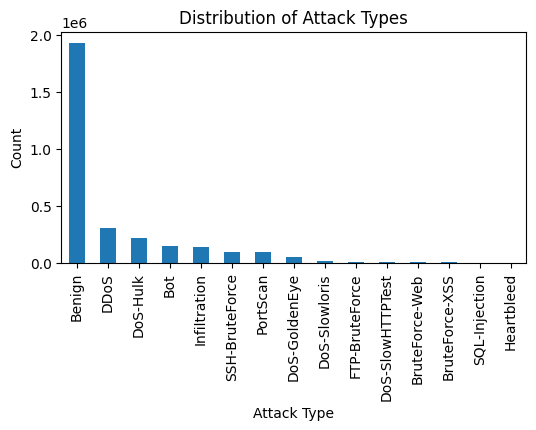

In [24]:
# visualize attack types distribution
attack_counts = df_small['label'].value_counts()
plt.figure(figsize=(6, 3))
attack_counts.plot(kind='bar')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

In [25]:
df_small.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,2994597.0,1.528353e+07,3.355574e+07,1.000000,559.000000,66606.000000,5.202459e+06,1.200000e+08
flow_bytes_s,2994597.0,1.117978e+06,2.394532e+07,0.000000,102.577784,3189.262815,4.173546e+04,2.071000e+09
flow_packets_s,2994597.0,3.824576e+04,1.872109e+05,0.016701,1.943740,65.928270,4.524887e+03,4.000000e+06
fwd_packets_s,2994597.0,3.265011e+04,1.772349e+05,0.000000,1.171110,37.157720,2.663116e+03,3.000000e+06
bwd_packets_s,2994597.0,5.595652e+03,3.749719e+04,0.000000,0.171535,17.435228,3.573662e+02,2.000000e+06
total_fwd_packet,2994597.0,1.717357e+01,1.250512e+03,1.000000,2.000000,2.000000,6.000000e+00,2.203660e+05
total_bwd_packets,2994597.0,1.068695e+01,9.557285e+02,0.000000,1.000000,2.000000,5.000000e+00,2.919220e+05
packet_length_mean,2994597.0,1.720932e+02,2.950190e+02,0.000000,6.000000,63.333333,1.230000e+02,3.337143e+03
packet_length_std,2994597.0,3.054636e+02,6.097945e+02,0.000000,2.927700,42.722359,3.280640e+02,4.731522e+03
packet_length_max,2994597.0,9.854363e+02,1.956639e+03,0.000000,6.000000,122.000000,9.760000e+02,2.482000e+04


In [31]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2994597 entries, 0 to 3999998
Data columns (total 39 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_duration               float64
 1   flow_bytes_s                float64
 2   flow_packets_s              float64
 3   fwd_packets_s               float64
 4   bwd_packets_s               float64
 5   total_fwd_packet            int64  
 6   total_bwd_packets           int64  
 7   packet_length_mean          float64
 8   packet_length_std           float64
 9   packet_length_max           int64  
 10  packet_length_min           int64  
 11  fwd_packet_length_mean      float64
 12  fwd_packet_length_std       float64
 13  bwd_packet_length_mean      float64
 14  bwd_packet_length_std       float64
 15  flow_iat_mean               float64
 16  flow_iat_std                float64
 17  flow_iat_max                float64
 18  fwd_iat_mean                float64
 19  fwd_iat_std               

In [36]:
# Multiclass labels 
print("MULTICLASS LABEL DISTRIBUTION  (Label column)")

label_counts = df_small['label'].value_counts()
label_pct    = df_small['label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count"      : label_counts,
    "Percentage" : label_pct.round(3)
})
print(summary.to_string())
print(df_small['binary_label'].value_counts())

MULTICLASS LABEL DISTRIBUTION  (Label column)
                    Count  Percentage
label                                
Benign            1930266      64.458
DDoS               299928      10.016
DoS-Hulk           212596       7.099
Bot                145921       4.873
Infiltration       136835       4.569
SSH-BruteForce      97198       3.246
PortScan            90694       3.029
DoS-GoldenEye       51637       1.724
DoS-Slowloris       15289       0.511
FTP-BruteForce       5984       0.200
DoS-SlowHTTPTest     5282       0.176
BruteForce-Web       1976       0.066
BruteForce-XSS        880       0.029
SQL-Injection         100       0.003
Heartbleed             11       0.000
binary_label
0    1930266
1    1064331
Name: count, dtype: int64


## Split x and y

In [46]:
# features and target
X = df_small.drop(columns=["label", "binary_label"], errors="ignore").copy()
y = df_small["binary_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (2994597, 37)
y shape: (2994597,)
binary_label
0    1930266
1    1064331
Name: count, dtype: int64


## checking outliers + caping for supervised 

In [ ]:
# outlier_report = []

# for col in X.columns:
#     q1 = X[col].quantile(0.25)
#     q3 = X[col].quantile(0.75)
#     iqr = q3 - q1
    
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
    
#     outliers = ((X[col] < lower) | (X[col] > upper)).sum()
#     percent = outliers / len(X) * 100
    
#     outlier_report.append({
#         "feature": col,
#         "outliers": outliers,
#         "percent": percent
#     })

# outlier_report = pd.DataFrame(outlier_report).sort_values("percent", ascending=False)
# outlier_report.head(20)

,feature,outliers,percent
33,dst_port,712665,23.798361
19,fwd_iat_std,698876,23.337898
3,fwd_packets_s,675991,22.573689
36,total_length_of_bwd_packet,674932,22.538325
2,flow_packets_s,673357,22.485730
31,idle_mean,668901,22.336929
20,bwd_iat_mean,659469,22.021962
4,bwd_packets_s,642890,21.468331
34,protocol,637092,21.274716
16,flow_iat_std,628024,20.971904


In [ ]:
# def cap_outliers_iqr(df):
#     df = df.copy()
#     for col in df.columns:
#         q1 = df[col].quantile(0.25)
#         q3 = df[col].quantile(0.75)
#         iqr = q3 - q1
        
#         lower = q1 - 1.5 * iqr
#         upper = q3 + 1.5 * iqr
        
#         df[col] = df[col].clip(lower=lower, upper=upper)
#     return df

## Unsupervised pipeline

In [49]:
# normal only data-set
X_normal = X[y == 0].copy()
X_attack = X[y == 1].copy()

print("Normal only:", X_normal.shape)
print("Attack only:", X_attack.shape)

Normal only: (1930266, 37)
Attack only: (1064331, 37)


In [39]:
# split normal for training
X_train_unsup, X_val_normal_unsup = train_test_split(
    X_normal,
    test_size=0.20,
    random_state=42
)

print("Unsupervised train normal:", X_train_unsup.shape)
print("Unsupervised val normal:  ", X_val_normal_unsup.shape)

Unsupervised train normal: (1544212, 37)
Unsupervised val normal:   (386054, 37)


In [40]:
# mixed validation/test from full X and y
X_val_unsup, X_test_unsup, y_val_unsup, y_test_unsup = train_test_split(
    X, y,
    test_size=0.50,
    stratify=y,
    random_state=42
)

print("Unsupervised mixed val:", X_val_unsup.shape, y_val_unsup.shape)
print("Unsupervised mixed test:", X_test_unsup.shape, y_test_unsup.shape)

Unsupervised mixed val: (1497298, 37) (1497298,)
Unsupervised mixed test: (1497299, 37) (1497299,)


In [ ]:
# scaling
robust_scaler_unsup = RobustScaler()
standard_scaler_unsup = StandardScaler()

X_train_unsup_robust = robust_scaler_unsup.fit_transform(X_train_unsup) 
X_val_normal_unsup_robust = robust_scaler_unsup.transform(X_val_normal_unsup)
X_val_unsup_robust = robust_scaler_unsup.transform(X_val_unsup)
X_test_unsup_robust = robust_scaler_unsup.transform(X_test_unsup)

X_train_unsup_scaled = standard_scaler_unsup.fit_transform(X_train_unsup_robust)
X_val_normal_unsup_scaled = standard_scaler_unsup.transform(X_val_normal_unsup_robust)
X_val_unsup_scaled = standard_scaler_unsup.transform(X_val_unsup_robust)
X_test_unsup_scaled = standard_scaler_unsup.transform(X_test_unsup_robust)

print("Unsupervised train normal scaled:", X_train_unsup_scaled.shape)
print("Unsupervised val normal scaled:  ", X_val_normal_unsup_scaled.shape)
print("Unsupervised mixed val scaled:   ", X_val_unsup_scaled.shape)
print("Unsupervised mixed test scaled:  ", X_test_unsup_scaled.shape)

Unsupervised train normal scaled: (1544212, 37)
Unsupervised val normal scaled:   (386054, 37)
Unsupervised mixed val scaled:    (1497298, 37)
Unsupervised mixed test scaled:   (1497299, 37)


In [ ]:
output_dir = Path("processed_outputs")
output_dir.mkdir(exist_ok=True)

joblib.dump(X_train_unsup_scaled, output_dir / "X_train_unsupervised_scaled.pkl")
joblib.dump(X_val_normal_unsup_scaled, output_dir / "X_val_normal_unsupervised_scaled.pkl")

joblib.dump(X_val_unsup_scaled, output_dir / "X_val_unsupervised_scaled.pkl")
joblib.dump(X_test_unsup_scaled, output_dir / "X_test_unsupervised_scaled.pkl")

joblib.dump(y_val_unsup, output_dir / "y_val_unsupervised.pkl")
joblib.dump(y_test_unsup, output_dir / "y_test_unsupervised.pkl")

joblib.dump(robust_scaler_unsup, output_dir / "robust_scaler_unsupervised.pkl")
joblib.dump(standard_scaler_unsup, output_dir / "standard_scaler_unsupervised.pkl")

print("Unsupervised files saved.")

Unsupervised files saved.


In [43]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, output_dir / "feature_names.pkl")

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 37
['flow_duration', 'flow_bytes_s', 'flow_packets_s', 'fwd_packets_s', 'bwd_packets_s', 'total_fwd_packet', 'total_bwd_packets', 'packet_length_mean', 'packet_length_std', 'packet_length_max', 'packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_mean', 'bwd_iat_std', 'down_up_ratio', 'fwd_act_data_pkts', 'syn_flag_count', 'ack_flag_count', 'rst_flag_count', 'psh_flag_count', 'fin_flag_count', 'active_mean', 'active_std', 'idle_mean', 'idle_std', 'dst_port', 'protocol', 'total_length_of_fwd_packet', 'total_length_of_bwd_packet']


## Supervised pipeline

In [82]:
# Attack labels in CICIDS-2018 (exclude 'Benign')
attack_df = df_small[df_small['label'] != 'Benign'].copy()

print(f"Attack samples only: {len(attack_df)}")
print(attack_df['label'].value_counts())

Attack samples only: 1064331
label
DDoS                299928
DoS-Hulk            212596
Bot                 145921
Infiltration        136835
SSH-BruteForce       97198
PortScan             90694
DoS-GoldenEye        51637
DoS-Slowloris        15289
FTP-BruteForce        5984
DoS-SlowHTTPTest      5282
BruteForce-Web        1976
BruteForce-XSS         880
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


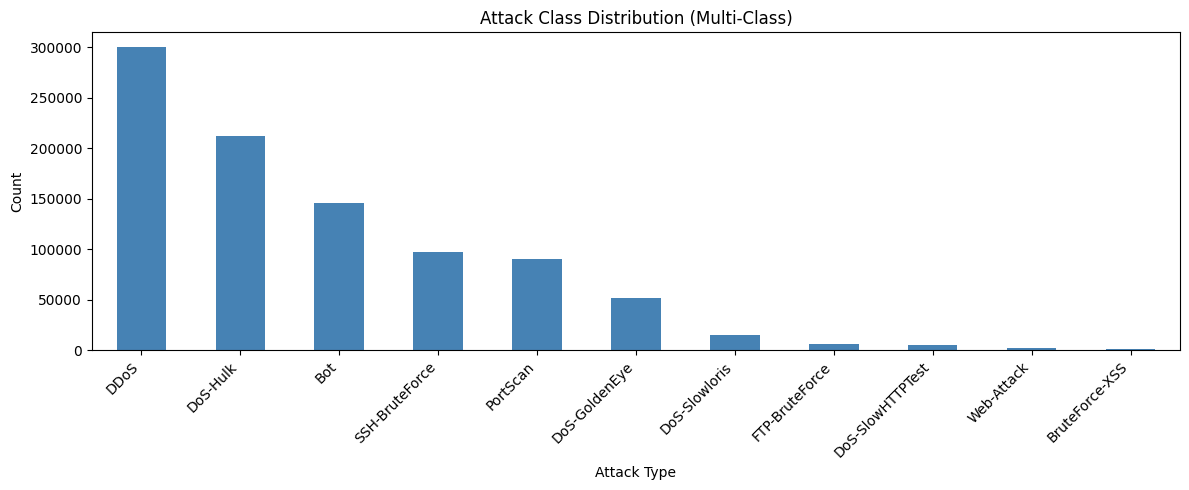

In [83]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title("Attack Class Distribution (Multi-Class)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [84]:
# features and target
X = attack_df.drop(columns=["label", "binary_label"], errors="ignore").copy()
y = attack_df["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (1064331, 37)
y shape: (1064331,)
label
DDoS                299928
DoS-Hulk            212596
Bot                 145921
Infiltration        136835
SSH-BruteForce       97198
PortScan             90694
DoS-GoldenEye        51637
DoS-Slowloris        15289
FTP-BruteForce        5984
DoS-SlowHTTPTest      5282
BruteForce-Web        1976
BruteForce-XSS         880
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


In [85]:
print(y.value_counts())

label
DDoS                299928
DoS-Hulk            212596
Bot                 145921
Infiltration        136835
SSH-BruteForce       97198
PortScan             90694
DoS-GoldenEye        51637
DoS-Slowloris        15289
FTP-BruteForce        5984
DoS-SlowHTTPTest      5282
BruteForce-Web        1976
BruteForce-XSS         880
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


In [86]:
# Drop Heartbleed
attack_df = attack_df[attack_df['label'] != 'Heartbleed'].copy()
print(f"After dropping Heartbleed  : {len(attack_df):,}")

# Drop Infiltration
attack_df = attack_df[attack_df['label'] != 'Infiltration'].copy()
print(f"After dropping Infiltration: {len(attack_df):,}")

# Merge SQL-Injection + BruteForce-Web → Web-Attack
attack_df['label'] = attack_df['label'].replace({
    'SQL-Injection'  : 'Web-Attack',
    'BruteForce-Web' : 'Web-Attack',
    'BruteForce-XSS' : 'Web-Attack'
})

After dropping Heartbleed  : 1,064,320
After dropping Infiltration: 927,485


In [87]:
print("Final Class Distribution:")
print(attack_df['label'].value_counts())
print(f"\nTotal samples : {len(attack_df):,}")
print(f"Total classes : {attack_df['label'].nunique()}")

Final Class Distribution:
label
DDoS                299928
DoS-Hulk            212596
Bot                 145921
SSH-BruteForce       97198
PortScan             90694
DoS-GoldenEye        51637
DoS-Slowloris        15289
FTP-BruteForce        5984
DoS-SlowHTTPTest      5282
Web-Attack            2956
Name: count, dtype: int64

Total samples : 927,485
Total classes : 10


In [88]:
X = attack_df.drop(columns=['label', 'binary_label'], errors='ignore').copy()
y = attack_df['label'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (927485, 37)
y shape: (927485,)


In [89]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClass Mapping:")
for i, cls in enumerate(le.classes_):
    count = (y == cls).sum()
    print(f"  {i} → {cls:<25} ({count:>7,} samples)")


Class Mapping:
  0 → Bot                       (145,921 samples)
  1 → DDoS                      (299,928 samples)
  2 → DoS-GoldenEye             ( 51,637 samples)
  3 → DoS-Hulk                  (212,596 samples)
  4 → DoS-SlowHTTPTest          (  5,282 samples)
  5 → DoS-Slowloris             ( 15,289 samples)
  6 → FTP-BruteForce            (  5,984 samples)
  7 → PortScan                  ( 90,694 samples)
  8 → SSH-BruteForce            ( 97,198 samples)
  9 → Web-Attack                (  2,956 samples)


In [90]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nSplit Sizes:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")


Split Sizes:
  Train : (649239, 37)
  Val   : (139123, 37)
  Test  : (139123, 37)


In [91]:
#Scaling (fit ONLY on train)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [92]:
from imblearn.over_sampling import SMOTE
#SMOTE — Oversample minorities (on train only)
sampling_targets_over = {
    le.transform(['Web-Attack'])[0]       : 20000,
    le.transform(['DoS-SlowHTTPTest'])[0] : 15000,
    le.transform(['FTP-BruteForce'])[0]   : 15000,
}

smote = SMOTE(
    sampling_strategy=sampling_targets_over,
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE:")
print(f"  Train shape: {X_train_res.shape}")


After SMOTE:
  Train shape: (689284, 37)


In [93]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
for idx, w in class_weight_dict.items():
    print(f"  {le.classes_[idx]:<25} weight: {w:.4f}")

Class Weights:
  Bot                       weight: 0.6748
  DDoS                      weight: 0.3283
  DoS-GoldenEye             weight: 1.9069
  DoS-Hulk                  weight: 0.4632
  DoS-SlowHTTPTest          weight: 4.5952
  DoS-Slowloris             weight: 6.4407
  FTP-BruteForce            weight: 4.5952
  PortScan                  weight: 1.0857
  SSH-BruteForce            weight: 1.0131
  Web-Attack                weight: 3.4464


In [94]:
import numpy as np

print("Final Training Class Distribution:")
unique, counts = np.unique(y_train_res, return_counts=True)

sorted_idx = np.argsort(counts)[::-1]

for cls_idx, cnt in zip(unique[sorted_idx], counts[sorted_idx]):
    bar = '█' * (cnt // 5000)
    print(f"  {le.classes_[cls_idx]:<25} {cnt:>7,}  {bar}")

print(f"\n  Total training samples: {len(y_train_res):,}")

Final Training Class Distribution:
  DDoS                      209,949  █████████████████████████████████████████
  DoS-Hulk                  148,817  █████████████████████████████
  Bot                       102,145  ████████████████████
  SSH-BruteForce             68,039  █████████████
  PortScan                   63,486  ████████████
  DoS-GoldenEye              36,146  ███████
  Web-Attack                 20,000  ████
  FTP-BruteForce             15,000  ███
  DoS-SlowHTTPTest           15,000  ███
  DoS-Slowloris              10,702  ██

  Total training samples: 689,284


In [95]:
# Save Everything
output_dir = Path("processed_outputs")
output_dir.mkdir(exist_ok=True)

# Resampled train (use this for model training)
joblib.dump(X_train_res,        output_dir / "X_train_supervised.pkl")
joblib.dump(y_train_res,        output_dir / "y_train_supervised.pkl")

# Original scaled val/test (never resample these)
joblib.dump(X_val_scaled,       output_dir / "X_val_supervised.pkl")
joblib.dump(X_test_scaled,      output_dir / "X_test_supervised.pkl")
joblib.dump(y_val,              output_dir / "y_val_supervised.pkl")
joblib.dump(y_test,             output_dir / "y_test_supervised.pkl")

# Artifacts
joblib.dump(scaler,             output_dir / "scaler_supervised.pkl")
joblib.dump(le,                 output_dir / "label_encoder_supervised.pkl")
joblib.dump(class_weight_dict,  output_dir / "class_weights_supervised.pkl")

print("\nAll files saved to processed_outputs")


All files saved to processed_outputs
